# 00 Intuition

This notebook builds first intuition for motif discovery. The goal is simple: create a noisy time series, inject the same shape multiple times, and visually confirm that some subsequences clearly repeat before any formal algorithm is used.

In [1]:
from pathlib import Path
import sys

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if candidate.name == "matrix_profile_lab":
        LAB_ROOT = candidate
        break
else:
    raise RuntimeError("Open this notebook from inside matrix_profile_lab.")

if str(LAB_ROOT) not in sys.path:
    sys.path.insert(0, str(LAB_ROOT))

from utils.data_generators import repeated_pattern_series
from utils.plotting import plot_motif_alignment, plot_series_with_windows


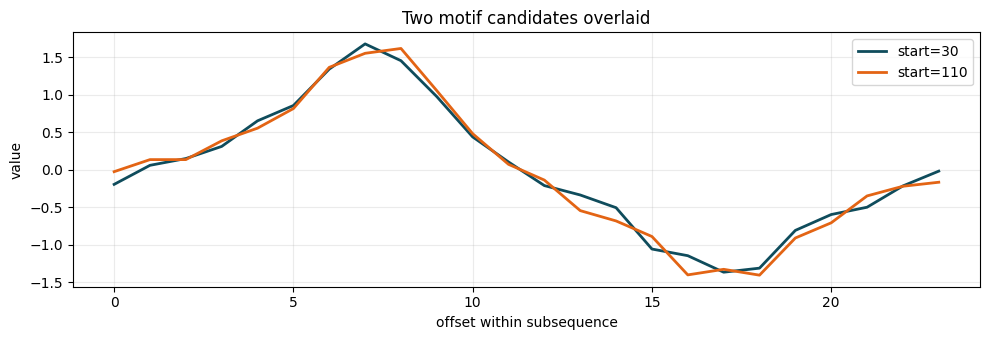

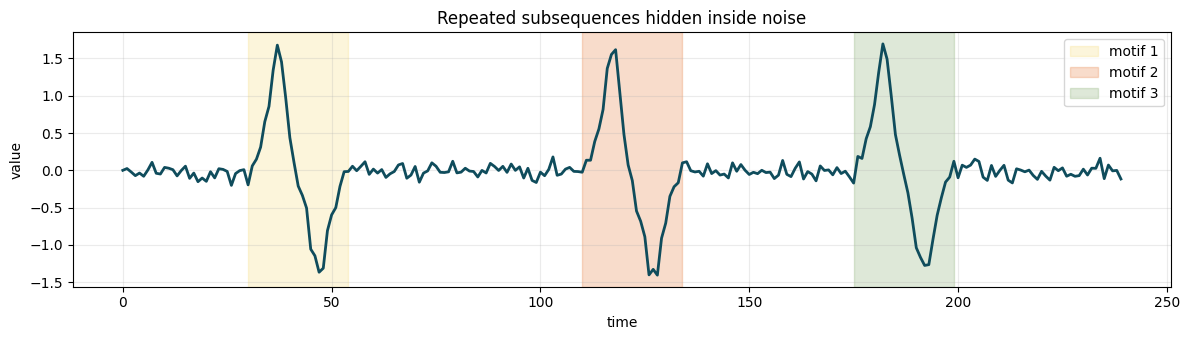

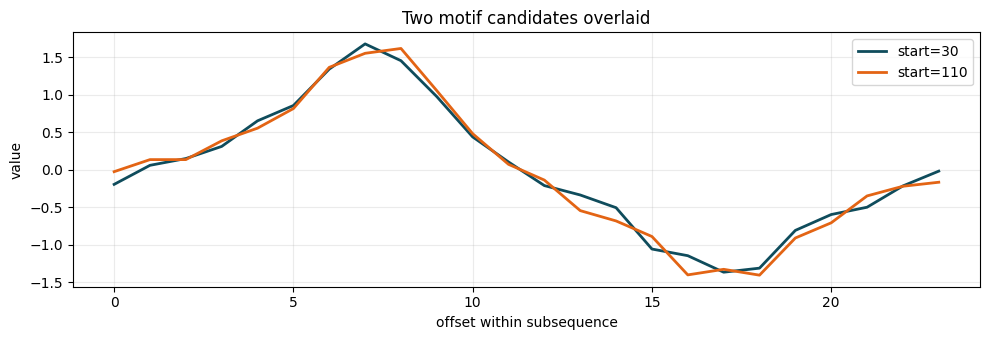

In [2]:
series, motif, motif_positions = repeated_pattern_series(
    length=240,
    motif_length=24,
    motif_positions=(30, 110, 175),
    noise=0.08,
    seed=7,
)

plot_series_with_windows(
    series,
    [(start, start + len(motif)) for start in motif_positions],
    title="Repeated subsequences hidden inside noise",
    labels=["motif 1", "motif 2", "motif 3"],
)

plot_motif_alignment(
    series,
    motif_positions[0],
    motif_positions[1],
    len(motif),
    title="Two motif candidates overlaid",
)


## Measuring Similarity: The Intuition of Distance
We can see visually when shapes look similar. But how does a computer measure this?
We use Euclidean Distance between the data points. Let's manually compare two similar patches and one different patch to see how the math aligns with our intuition.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a simple synthetic series with repeated shapes (sine wave + noise)
np.random.seed(42)
time = np.arange(500)
ts = np.sin(time * 0.1) + np.random.normal(0, 0.15, 500)

# Extract 3 windows of length 50
window_size = 50
cycle_length = int(2 * np.pi / 0.1)

patch_A = ts[50 : 50 + window_size]  # A sine peak
patch_B = ts[50 + cycle_length : 50 + cycle_length + window_size]  # The next sine peak
patch_C = ts[100 : 100 + window_size]  # A sine trough

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(patch_A, label='Patch A (Peak)', color='blue')
ax.plot(patch_B, label='Patch B (Peak)', color='cyan', linestyle='--')
ax.plot(patch_C, label='Patch C (Trough)', color='red')
ax.set_title("Comparing Subsequences (Patches)")
ax.legend()
plt.show()

# Calculate Euclidean Distance
dist_AB = np.linalg.norm(patch_A - patch_B)
dist_AC = np.linalg.norm(patch_A - patch_C)

print(f"Distance between A and B (Similar): {dist_AB:.2f}")
print(f"Distance between A and C (Different): {dist_AC:.2f}")

## The Need for Z-Normalization
What if the identical shape happens but at a different baseline or amplitude (e.g. market volatility changes, or baseline price trends up)?
A simple Euclidean distance would say they are far apart, even if the 'shape' is identical.
This is why we Z-normalize patches before comparing them in Matrix Profile.

In [ ]:
# Create a shifted and scaled version of Patch A
patch_D = (patch_A * 2.5) + 5.0

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(patch_A, label='Patch A (Original)', color='blue')
ax.plot(patch_D, label='Patch D (Scaled & Shifted)', color='green')
ax.set_title("Identical Shape, Different Scale and Mean")
ax.legend()
plt.show()

print(f"Raw Euclidean Distance between A and D: {np.linalg.norm(patch_A - patch_D):.2f}")

# Now let's Z-Normalize
def z_normalize(patch):
    std = np.std(patch)
    if std == 0:
        return np.zeros_like(patch)
    return (patch - np.mean(patch)) / std

norm_A = z_normalize(patch_A)
norm_D = z_normalize(patch_D)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(norm_A, label='Normalized Patch A', color='blue', linewidth=3)
ax.plot(norm_D, label='Normalized Patch D', color='green', linestyle='--')
ax.set_title("Z-Normalized Patches Overlap Perfectly")
ax.legend()
plt.show()

print(f"Normalized Euclidean Distance between A and D: {np.linalg.norm(norm_A - norm_D):.2f}")

## Moving to the Matrix Profile
If we want to find the most similar pair of sequences in the entire time series (the best Motif), we would need to:
1. Extract **every** possible sliding window of length $m$.
2. Z-normalize each window.
3. Compute the Euclidean distance between **every** pair of windows.
4. Find the pair with the absolute minimum distance.

This brute-force approach requires $O(n^2)$ time complexity, which is painfully slow for large datasets. 

**The Matrix Profile** is an elegant algorithm and data structure that answers this exact problem efficiently. We will dive into its core computation in the next notebooks!